# 3 (v1) — Comparing value-function targets for time2success

**Question.** v7's T2S head is trained with a Monte-Carlo target: the true,
already-observed countdown `first_success_frame - t`, computed after the
episode finishes. That target only exists for successful episodes — notebook
1's `build_labels` gives every row of a failed episode the same flat
`CENSOR_LABEL = 300.0` because there is no success frame to count down to.

This notebook sets up **3 target-construction methods x 2 data conditions =
6 combinations** and asks: does bootstrapping (TD) let the model use failed
episodes more usefully than the flat-censor hack does, and does that show up
in prediction accuracy, curve shape, and rank correlation with ground truth?

| | successful-only | successful + failed |
|---|---|---|
| **MC** | v7 baseline (this notebook: `mc_succ`) | flat `CENSOR_LABEL` on every row of a failed episode, per notebook 1 (`mc_all`) |
| **TD(0)** | one-step bootstrap, no failed episodes to bootstrap into (`td0_succ`) | failed-episode rows bootstrap forward through the trajectory toward a `CENSOR_LABEL` value anchored only at the *last* frame, not smeared over every frame (`td0_all`) |
| **TD(&lambda;)** | same as TD(0) but each target blends the 1-step bootstrap with the full in-episode return (`tdlam_succ`) | same failed-episode handling as TD(0)_all, blended over the &lambda;-return (`tdlam_all`) |

**Evaluation, 3 kinds, all reported per combination:**
1. **Prediction of success time** — MAE / RMSE of predicted steps-remaining
   against the true countdown, pre-success frames only (post-success rows are
   a tied block of zeros and would flatter/depress error for reasons unrelated
   to accuracy).
2. **Pattern** — does the curve behave the way a countdown should: mostly
   non-increasing on a successful rollout, does it plateau near 0 after
   success, and — the check that has mattered most in v6/v7 — does it stay
   well above near-zero on a rollout that never succeeds (the "mistaking a
   stall for near-success" failure mode).
3. **Correlation** — Spearman rank correlation between the predicted sequence
   and the true countdown, per rollout, averaged over several seeds (same
   check as v7 Section 8).

**Four rollouts, six models each.** A single environment rollout is recorded
per scenario (success / failure / random / almost-success) — capturing frames
and the raw observation sequence. Because the T2S models only *read* state and
never act, all 6 trained models can then be replayed against that one fixed
observation sequence, so we get a fair side-by-side without needing 24
separate rollouts.

**almost-success** is a rollout that gets close but does not finish: a
checkpoint from partway through SAC training that reaches the peg-hole
alignment phase but does not reliably complete insertion within the horizon.
If your checkpoint set finishes anyway, the fallback below truncates the
rollout a fixed number of frames before its own success frame.


## 1. Setup — reused from notebooks 1 and 2

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import metaworld
import os, json, pickle, glob, copy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
from stable_baselines3 import SAC
import matplotlib.pyplot as plt
import imageio
from IPython.display import Video

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39

HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]

DATASET_DIR = "./data/state_space_datasetV7"
MODEL_DIR   = "./checkpoints/t2s_compare_v1"
os.makedirs(MODEL_DIR, exist_ok=True)

CENSOR_LABEL = 300.0   # same constant as notebook 1 / notebook 2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [2]:
def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

def find_wrapper(env, attr):
    w = env
    while not hasattr(w, attr):
        if not hasattr(w, "env"):
            raise AttributeError(attr)
        w = w.env
    return w

FIXED_TASK_PATH = os.path.join(DATASET_DIR, "fixed_task.pkl")

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        env.unwrapped.set_task(pickle.load(f))
    return env

ckpts = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
               key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))
numbered = [p for p in ckpts if any(c.isdigit() for c in os.path.basename(p))]
FINAL_CKPT = [p for p in ckpts if "final" in os.path.basename(p)][0]
EARLY_CKPT = numbered[0]
# heuristic "partway trained" checkpoint for the almost-success rollout — adjust
# the index if your checkpoint spacing puts this too close to either end.
MID_CKPT = numbered[int(len(numbered) * 0.7)]

expert_pol = SAC.load(FINAL_CKPT)
early_pol  = SAC.load(EARLY_CKPT)
mid_pol    = SAC.load(MID_CKPT)
print("expert:", os.path.basename(FINAL_CKPT))
print("early :", os.path.basename(EARLY_CKPT))
print("mid   :", os.path.basename(MID_CKPT), "(almost-success candidate)")

expert: sac_peg_insert_final.zip
early : sac_peg_insert_100000.zip
mid   : sac_peg_insert_500000.zip (almost-success candidate)


## 2. Load the dataset and build next-state / terminal bookkeeping

Rows are already in per-episode time order (notebook 1 concatenates each episode's frames in sequence), so `next_obs[i] = X[i+1]` whenever row `i+1` belongs to the same episode. Two kinds of terminal row:

- **success terminal** — `y_steps == 0`, true value is exactly 0.
- **failure terminal** — last row of an episode that never reached success, true value is undefined; anchored at `CENSOR_LABEL`, matching notebook 1's own hack, so TD's failure-handling is a fair comparison against MC's rather than a different assumption smuggled in.

In [3]:
raw = np.load(os.path.join(DATASET_DIR, "dataset.npz"))
X_all, y_all = raw["X"], raw["y_steps"]
stage_all, episode_ids_all, frame_idxs_all = raw["stage"], raw["episode_ids"], raw["frame_idxs"]

print(f"{X_all.shape[0]} rows, {len(np.unique(episode_ids_all))} episodes")

is_failed_episode = np.array([
    np.all(y_all[episode_ids_all == ep] == CENSOR_LABEL)
    for ep in episode_ids_all
])
print(f"rows from failed episodes: {is_failed_episode.mean():.1%}")

def build_bookkeeping(X, y, episode_ids, frame_idxs):
    """next_obs / is_terminal / terminal_value for TD targets."""
    n = len(X)
    next_obs = np.zeros_like(X)
    is_terminal = np.zeros(n, dtype=bool)
    terminal_value = np.zeros(n, dtype=np.float32)
    for i in range(n):
        same_ep_next = (i + 1 < n) and (episode_ids[i + 1] == episode_ids[i])
        if y[i] == 0.0:
            is_terminal[i] = True
            terminal_value[i] = 0.0
        elif not same_ep_next:
            is_terminal[i] = True
            terminal_value[i] = CENSOR_LABEL
        else:
            next_obs[i] = X[i + 1]
    return next_obs, is_terminal, terminal_value

next_obs_all, is_terminal_all, terminal_value_all = build_bookkeeping(
    X_all, y_all, episode_ids_all, frame_idxs_all)
print(f"terminal rows: {is_terminal_all.mean():.1%} "
      f"(success terminals: {(is_terminal_all & (terminal_value_all == 0)).sum()}, "
      f"failure terminals: {(is_terminal_all & (terminal_value_all == CENSOR_LABEL)).sum()})")

106000 rows, 212 episodes
rows from failed episodes: 39.6%
terminal rows: 52.7% (success terminals: 55805, failure terminals: 84)


### Trim the long flat tail (same `CONFIRM_BUFFER` cut as notebook 2, applied identically to both data conditions so it can't confound the comparison)

In [4]:
CONFIRM_BUFFER = 20
keep = np.zeros(len(y_all), dtype=bool)
for ep in np.unique(episode_ids_all):
    idx = np.flatnonzero(episode_ids_all == ep)
    if is_failed_episode[idx[0]]:
        keep[idx] = True   # failed episodes have no zero-crossing to trim to
        continue
    zero_pos = np.flatnonzero(y_all[idx] == 0.0)
    end_pos = min(zero_pos[0] + CONFIRM_BUFFER, len(idx) - 1)
    keep[idx[:end_pos + 1]] = True

X_all, y_all = X_all[keep], y_all[keep]
stage_all, episode_ids_all, frame_idxs_all = stage_all[keep], episode_ids_all[keep], frame_idxs_all[keep]
next_obs_all, is_terminal_all, terminal_value_all = (
    next_obs_all[keep], is_terminal_all[keep], terminal_value_all[keep])
is_failed_episode = is_failed_episode[keep]
print("rows after trim:", len(X_all))

rows after trim: 52883


## 3. Split and normalize — one split, two data views

Group split by episode so adjacent frames can't leak across train/val. The **successful-only** view drops failed-episode rows; the **successful+failed** view keeps them. Normalization stats come from the successful-only training rows in both views, so the two conditions are comparable on the same input scale.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
tr_all, va_all = next(gss.split(X_all, y_all, groups=episode_ids_all))

succ_mask = ~is_failed_episode
tr_succ = tr_all[succ_mask[tr_all]]
va_succ = va_all[succ_mask[va_all]]

x_mean = X_all[tr_succ].mean(axis=0)
x_std  = X_all[tr_succ].std(axis=0)
x_std  = np.where(x_std < 1e-4, 1.0, x_std)

def normalize(X):
    return ((X - x_mean) / x_std).astype(np.float32)

Xn_all = normalize(X_all)
# next_obs of a terminal row is a zero placeholder never used as model input;
# normalizing it is harmless since it's multiplied by is_terminal==True downstream.
next_obs_n_all = normalize(next_obs_all)

DATA = {
    "succ": dict(rows_tr=tr_succ, rows_va=va_succ),
    "all":  dict(rows_tr=tr_all,  rows_va=va_all),
}
for cond, d in DATA.items():
    print(f"{cond:5s}: {len(d['rows_tr'])} train rows, {len(d['rows_va'])} val rows")

succ : 9269 train rows, 1614 val rows
all  : 44769 train rows, 8114 val rows


## 4. Model — plain T2S regressor

Single head (this ablation is about the *target*, not the auxiliary stage loss from v7), same encoder shape and the same `Softplus` floor-at-zero as v7.

In [7]:
class T2SModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
        )
        self.t2s_head = nn.Sequential(nn.Linear(hidden, 1), nn.Softplus())

    def forward(self, x):
        return self.t2s_head(self.encoder(x)).squeeze(-1)

    predict_t2s_only = forward

## 5. Target construction — MC / TD(0) / TD(&lambda;)

MC needs no bootstrapping: the target is just `y_steps`, i.e. notebook 1's ground truth (0 on successes, flat `CENSOR_LABEL` on every row of a failure). TD(0) and TD(&lambda;) bootstrap off a **target network** snapshot — refreshed every few epochs rather than every step, for stability — recomputing targets each refresh from the current estimate of `V(s_{t+1})`.

TD(&lambda;) is computed by exact backward recursion per episode (the offline data holds complete trajectories, so no eligibility trace is needed — this is the closed-form &lambda;-return).

In [8]:
@torch.no_grad()
def bootstrap_values(net, obs_n):
    net.eval()
    return net(torch.tensor(obs_n, device=device)).cpu().numpy()

def build_targets(method, net, rows, gamma=1, lam=0.9):
    y = y_all[rows]
    if method == "mc":
        return y.astype(np.float32)

    nxt = next_obs_n_all[rows]
    term = is_terminal_all[rows]
    term_val = terminal_value_all[rows]
    v_next = bootstrap_values(net, nxt)

    if method == "td0":
        return np.where(term, term_val, 1.0 + gamma * v_next).astype(np.float32)

    if method == "tdlambda":
        target = np.zeros(len(rows), dtype=np.float32)
        eps = episode_ids_all[rows]
        frames = frame_idxs_all[rows]
        for ep in np.unique(eps):
            idx_local = np.flatnonzero(eps == ep)
            idx_local = idx_local[np.argsort(frames[idx_local])]
            G_next = None
            for pos in range(len(idx_local) - 1, -1, -1):
                i = idx_local[pos]
                if term[i]:
                    target[i] = term_val[i]
                else:
                    boot = 1.0 + gamma * v_next[i]
                    full = boot if G_next is None else 1.0 + gamma * G_next
                    target[i] = (1 - lam) * boot + lam * full
                G_next = target[i]
        return target

    raise ValueError(method)

## 6. Training loop — shared across all 6 combinations

MC trains against a fixed target the whole time (identical in spirit to notebook 2's loop). TD(0)/TD(&lambda;) refresh their regression target every `TARGET_REFRESH` epochs from a target-network snapshot, then train against that fixed batch of targets until the next refresh — this is the standard semi-gradient stabilization (same idea as a DQN target net).

In [9]:
EPOCHS, PATIENCE = 150, 20
TARGET_REFRESH = 5
GAMMA, LAMBDA = 0.99, 0.9

def train_one(method, condition, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    rows_tr = DATA[condition]["rows_tr"]
    rows_va = DATA[condition]["rows_va"]

    model = T2SModel(obs_dim=OBS_DIM).to(device)
    target_net = copy.deepcopy(model)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    Xn_tr, Xn_va = Xn_all[rows_tr], Xn_all[rows_va]
    y_va_true = y_all[rows_va]   # for the MSE readout we always score against real y

    best, stale = float("inf"), 0
    hist = []
    yb_tr = None
    for ep in range(EPOCHS):
        if method == "mc":
            if yb_tr is None:
                yb_tr = build_targets("mc", None, rows_tr)
        elif ep % TARGET_REFRESH == 0:
            target_net.load_state_dict(model.state_dict())
            yb_tr = build_targets(method, target_net, rows_tr, gamma=GAMMA, lam=LAMBDA)

        model.train()
        perm = np.random.permutation(len(rows_tr))
        for s in range(0, len(perm), 256):
            b = perm[s:s + 256]
            xb = torch.tensor(Xn_tr[b], device=device)
            yb = torch.tensor(yb_tr[b], device=device)
            opt.zero_grad()
            pred = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred_va = model(torch.tensor(Xn_va, device=device)).cpu().numpy()
        val_mse = float(np.mean((pred_va - y_va_true) ** 2))
        hist.append((ep, val_mse))

        if val_mse < best:
            best, stale = val_mse, 0
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f"{method}_{condition}.pt"))
        else:
            stale += 1
            if stale >= PATIENCE:
                break

    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f"{method}_{condition}.pt")))
    model.eval()
    print(f"{method:10s} / {condition:5s}: best val MSE (raw steps) = {best:.1f}, stopped epoch {ep}")
    return model, np.array(hist)

## 7. Run all 6 combinations

In [10]:
COMBOS = [(m, c) for m in ["mc", "td0", "tdlambda"] for c in ["succ", "all"]]

models, histories = {}, {}
for method, condition in COMBOS:
    key = f"{method}_{condition}"
    models[key], histories[key] = train_one(method, condition)

np.savez(os.path.join(MODEL_DIR, "normalization.npz"), x_mean=x_mean, x_std=x_std)

mc         / succ : best val MSE (raw steps) = 35.9, stopped epoch 149
mc         / all  : best val MSE (raw steps) = 466.1, stopped epoch 88
td0        / succ : best val MSE (raw steps) = 346.0, stopped epoch 149
td0        / all  : best val MSE (raw steps) = 54346.0, stopped epoch 149
tdlambda   / succ : best val MSE (raw steps) = 103.0, stopped epoch 75
tdlambda   / all  : best val MSE (raw steps) = 26842.2, stopped epoch 149


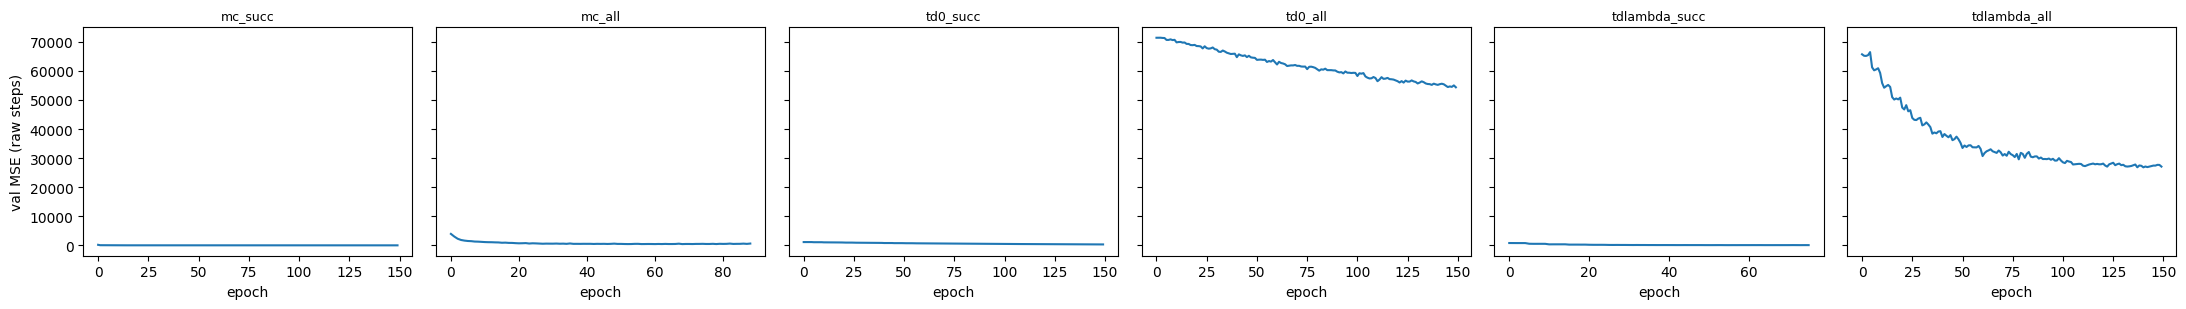

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(22, 3.2), sharey=True)
for ax, (method, condition) in zip(axes, COMBOS):
    key = f"{method}_{condition}"
    h = histories[key]
    ax.plot(h[:, 0], h[:, 1])
    ax.set_title(key, fontsize=9)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("val MSE (raw steps)")
plt.tight_layout(); plt.show()

## 8. Evaluation — prediction accuracy, pattern, correlation

All three are measured on live rollouts against the expert policy (ground truth is only well-defined pre-success), plus the failing-rollout minimum as the pattern check that has mattered most in v6/v7.

In [12]:
@torch.no_grad()
def predict_t2s(model, obs):
    x = torch.tensor(normalize(obs[None, :]), device=device)
    return float(model(x).item())

def eval_rollout(model, policy, seed, max_steps=500, random_policy=False):
    env = make_fixed_scene_env()
    obs, _ = env.reset(seed=seed)
    preds, success = [], None
    for t in range(max_steps):
        preds.append(predict_t2s(model, obs))
        a = env.action_space.sample() if random_policy else policy.predict(obs, deterministic=True)[0]
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    return np.array(preds), success

N_EVAL_SEEDS = 8
rows = []
for method, condition in COMBOS:
    key = f"{method}_{condition}"
    model = models[key]

    maes, rhos = [], []
    for seed in range(500, 500 + N_EVAL_SEEDS):
        preds, success = eval_rollout(model, expert_pol, seed=seed)
        if success is None:
            continue
        pre = preds[:success]                       # pre-success frames only
        truth = np.array([success - t for t in range(success)])
        if len(pre) < 5:
            continue
        maes.append(np.mean(np.abs(pre - truth)))
        rho, _ = spearmanr(pre, truth)
        rhos.append(rho)

    fail_preds, _ = eval_rollout(model, early_pol, seed=0)
    mono = np.mean(np.diff(fail_preds) <= 2.0)       # allow small noise, not a hard <=0
    succ_preds, succ_at = eval_rollout(model, expert_pol, seed=0)
    plateau = float(np.mean(succ_preds[succ_at:succ_at + 20])) if succ_at is not None else np.nan

    rows.append(dict(
        combo=key,
        mae_pre_success=np.mean(maes) if maes else np.nan,
        spearman_rho=np.mean(rhos) if rhos else np.nan,
        n_scored_seeds=len(maes),
        monotonicity_frac=mono,
        post_success_plateau=plateau,
        failing_rollout_min=float(fail_preds.min()),
    ))

results = pd.DataFrame(rows).set_index("combo")
results

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


,mae_pre_success,spearman_rho,n_scored_seeds,monotonicity_frac,post_success_plateau,failing_rollout_min
combo,,,,,,
mc_succ,2.624026,0.999674,8,0.917836,3.620488e-08,0.000000e+00
mc_all,12.600705,0.901324,8,0.987976,1.139575e-15,1.592927e+02
td0_succ,5.621835,0.999674,8,1.000000,1.474629e-02,4.726209e-07
td0_all,8.688092,0.991099,8,0.899800,1.843703e-05,2.084004e+01
tdlambda_succ,1.143159,1.000000,8,0.973948,2.083373e-03,2.567008e-12
tdlambda_all,2.572066,0.999457,8,0.917836,5.984871e-33,6.839123e+01


**Reading this table.** `mae_pre_success` and `spearman_rho` are the "prediction of success time" and "correlation" metrics; `monotonicity_frac` and `post_success_plateau` are the "pattern" checks. `failing_rollout_min` is the number that has tracked real RL behaviour throughout v6/v7 — successful-only models tend to read low (mistaking a stall for near-success), and the hoped-for effect of adding failure data (by any method) is that this number rises toward `CENSOR_LABEL` instead.

## 9. Four scenario rollouts, six models each

One environment rollout per scenario — frames + raw observation sequence are recorded once; each of the 6 trained models is then replayed against that same observation sequence, since none of them affect control.

In [14]:
def record_scenario(policy, out_path, seed=0, max_steps=500, random_policy=False,
                     truncate_before_success=None):
    env = make_fixed_scene_env(render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, obs_seq = [], []
    success = None
    for t in range(max_steps):
        frames.append(env.render())
        obs_seq.append(obs.copy())
        a = env.action_space.sample() if random_policy else policy.predict(obs, deterministic=True)[0]
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
            if truncate_before_success is not None:
                break
        if term or trunc:
            break
    env.close()

    if truncate_before_success is not None and success is not None:
        cut = max(1, success - truncate_before_success)
        frames, obs_seq = frames[:cut], obs_seq[:cut]
        success = None   # scenario now ends before completion, by construction

    imageio.mimsave(out_path, frames, fps=20)
    return dict(obs=np.array(obs_seq, dtype=np.float32), success=success,
                n=len(frames), path=out_path)

success_scn = record_scenario(expert_pol, "cmp_success.mp4", seed=0)
failure_scn = record_scenario(early_pol,  "cmp_failure.mp4", seed=0)
random_scn  = record_scenario(None, "cmp_random.mp4", seed=0, random_policy=True)

# almost-success: try the mid checkpoint first; if it still finishes, fall back
# to truncating a fixed number of frames before its own success.
almost_scn = record_scenario(mid_pol, "cmp_almost.mp4", seed=0)
if almost_scn["success"] is not None:
    print("mid checkpoint reached success — re-recording with a forced truncation")
    almost_scn = record_scenario(mid_pol, "cmp_almost.mp4", seed=0, truncate_before_success=15)

for name, r in [("success", success_scn), ("failure", failure_scn),
                ("random", random_scn), ("almost", almost_scn)]:
    print(f"{name:8s}: {r['n']:3d} frames, success at {r['success']}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


mid checkpoint reached success — re-recording with a forced truncation
success : 500 frames, success at 48
failure : 500 frames, success at None
random  : 500 frames, success at None
almost  :  51 frames, success at None


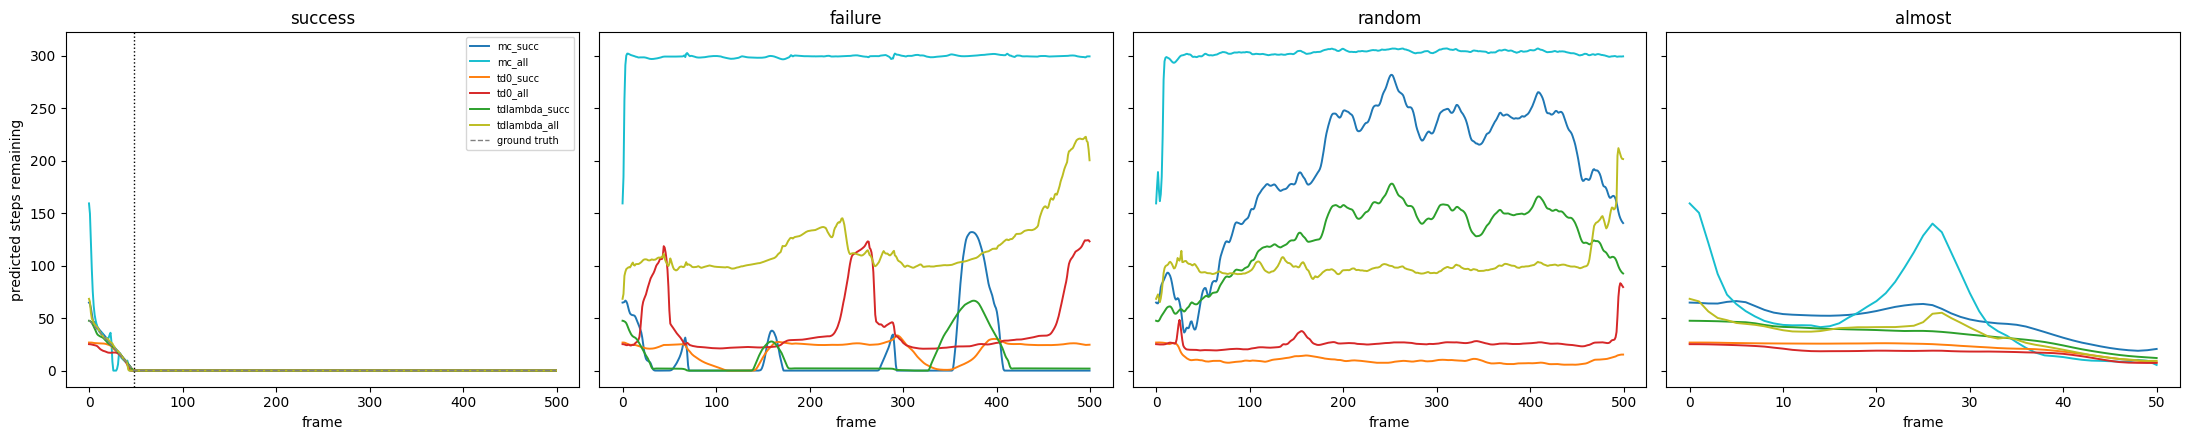

In [15]:
SCENARIOS = {"success": success_scn, "failure": failure_scn,
             "random": random_scn, "almost": almost_scn}
COLORS = dict(zip([f"{m}_{c}" for m, c in COMBOS],
                   ["tab:blue", "tab:cyan", "tab:orange", "tab:red", "tab:green", "tab:olive"]))

@torch.no_grad()
def predict_curve(model, obs_seq):
    x = torch.tensor(normalize(obs_seq), device=device)
    return model(x).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)
for ax, (name, scn) in zip(axes, SCENARIOS.items()):
    for key in COLORS:
        curve = predict_curve(models[key], scn["obs"])
        ax.plot(curve, label=key, color=COLORS[key], lw=1.4)
    if scn["success"] is not None:
        ax.axvline(scn["success"], color="black", ls=":", lw=1)
        truth = [max(0, scn["success"] - t) for t in range(scn["n"])]
        ax.plot(truth, "--", color="gray", lw=1, label="ground truth")
    ax.set_title(name)
    ax.set_xlabel("frame")
axes[0].set_ylabel("predicted steps remaining")
axes[0].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

### The four raw rollout videos

Watch alongside the comparison plot above — same frame axis.

In [ ]:
Video("cmp_success.mp4", embed=True)

In [ ]:
Video("cmp_failure.mp4", embed=True)

In [ ]:
Video("cmp_random.mp4", embed=True)

In [ ]:
Video("cmp_almost.mp4", embed=True)

## 10. Optional — composite video with the chart burned into each frame

Heavier to render (one matplotlib figure per frame x 4 scenarios), so it's kept separate from the lightweight raw-rollout videos above. Uncomment to run; useful for sharing a single clip rather than a plot + a video side by side.

In [ ]:
# def composite_video(scn, out_path, fps=20):
#     frames = imageio.mimread(scn["path"])
#     curves = {key: predict_curve(models[key], scn["obs"]) for key in COLORS}
#     out = []
#     for t in range(scn["n"]):
#         fig, ax = plt.subplots(figsize=(4, 3), dpi=100)
#         for key, curve in curves.items():
#             ax.plot(curve[:t + 1], color=COLORS[key], lw=1.2, label=key)
#         ax.set_xlim(0, scn["n"]); ax.axvline(t, color="black", lw=0.8)
#         ax.legend(fontsize=5, loc="upper right"); ax.set_ylabel("pred steps")
#         fig.canvas.draw()
#         chart = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
#         plt.close(fig)
#         h = frames[t].shape[0]
#         chart_r = np.array(Image := __import__("PIL.Image", fromlist=["Image"]).Image
#                             .fromarray(chart).resize((chart.shape[1] * h // chart.shape[0], h)))
#         out.append(np.concatenate([frames[t], chart_r], axis=1))
#     imageio.mimsave(out_path, out, fps=fps)
#
# for name, scn in SCENARIOS.items():
#     composite_video(scn, f"cmp_{name}_composite.mp4")